# Chilean Glacier Analysis: Multi-Dataset Comparison
## Focus on WA1 Cluster with Mass Balance and Runoff Analysis

**Datasets:** CR2MET, ERA5, CRU (2000-2020)  
**Reference:** Hugonnet et al. (2021) geodetic observations

## Study Area

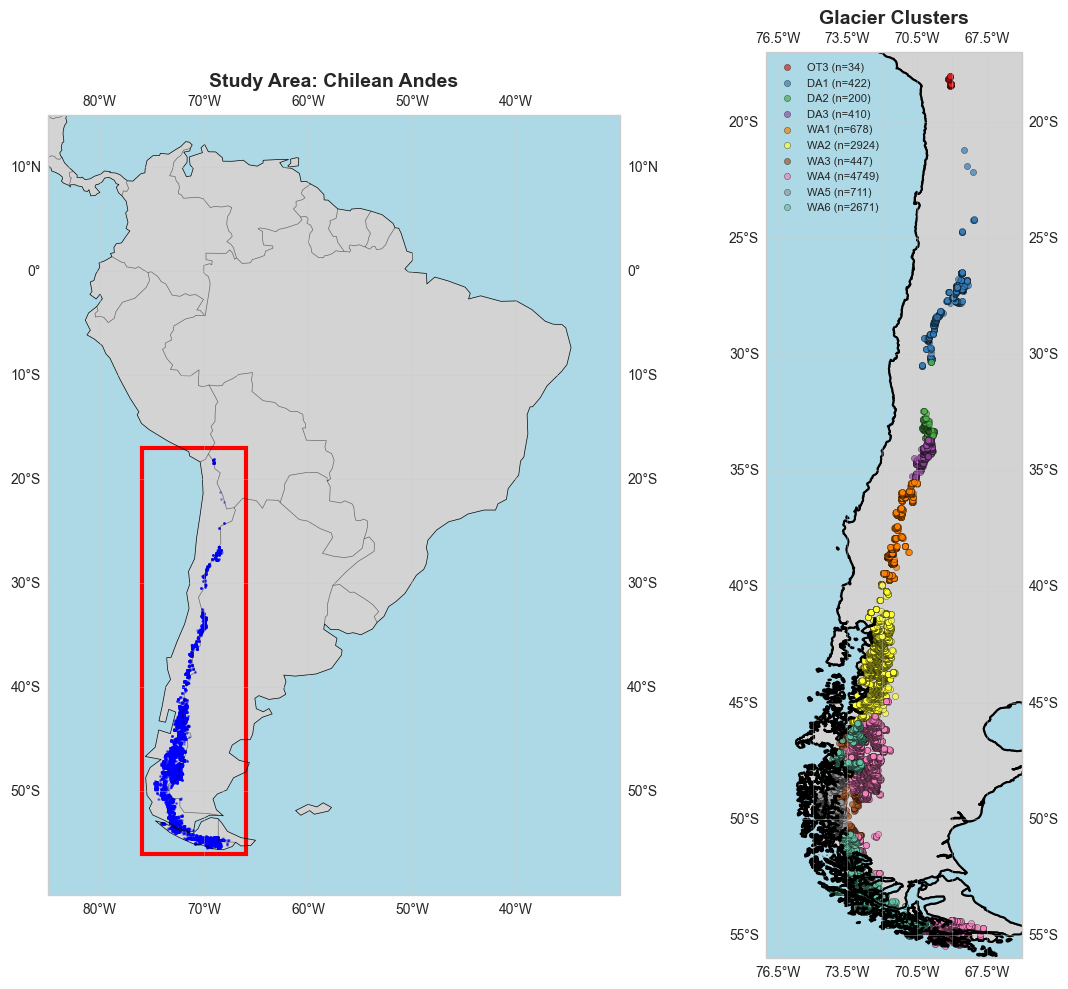

✓ Map saved to: Study_Area_Map.png


In [4]:
"""
Create study area map showing glacier clusters in Chile
"""

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load your cluster data
datos_rgi = pd.read_csv('/Users/milliespencer/Desktop/CR2_OGGM_Paper/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv')

# Create GeoDataFrame from your RGI data (assuming it has lat/lon columns)
# If your CSV has CenLat and CenLon:
gdf = gpd.GeoDataFrame(
    datos_rgi,
    geometry=gpd.points_from_xy(datos_rgi.CenLon, datos_rgi.CenLat),
    crs='EPSG:4326'
)

# Define cluster colors
cluster_colors = {
    'OT3': '#e41a1c',
    'DA1': '#377eb8',
    'DA2': '#4daf4a',
    'DA3': '#984ea3',
    'WA1': '#ff7f00',
    'WA2': '#ffff33',
    'WA3': '#a65628',
    'WA4': '#f781bf',
    'WA5': '#999999',
    'WA6': '#66c2a5'
}

# Create figure with two panels
fig = plt.figure(figsize=(12, 10))

# PANEL 1: South America context map
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_extent([-85, -30, -60, 15], crs=ccrs.PlateCarree())

# Add features
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none')
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)

# Highlight Chile
chile_bounds = [-76, -66, -56, -17]  # lon_min, lon_max, lat_min, lat_max
ax1.add_patch(Rectangle(
    xy=(chile_bounds[0], chile_bounds[2]),
    width=chile_bounds[1] - chile_bounds[0],
    height=chile_bounds[3] - chile_bounds[2],
    facecolor='none',
    edgecolor='red',
    linewidth=3,
    transform=ccrs.PlateCarree()
))

# Add all glaciers as small dots
ax1.scatter(gdf.CenLon, gdf.CenLat, s=1, c='blue', alpha=0.3, 
           transform=ccrs.PlateCarree(), label='Glaciers')

ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax1.set_title('Study Area: Chilean Andes', fontsize=14, fontweight='bold')

# PANEL 2: Chile detail with clusters
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_extent([-77, -66, -56, -17], crs=ccrs.PlateCarree())

# Add features
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=1.5)
ax2.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax2.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black')

# Plot each cluster with different colors
for cluster_name, color in cluster_colors.items():
    cluster_data = gdf[gdf['Cluster'] == cluster_name]
    if len(cluster_data) > 0:
        ax2.scatter(cluster_data.CenLon, cluster_data.CenLat, 
                   s=20, c=color, alpha=0.7, 
                   transform=ccrs.PlateCarree(),
                   label=f'{cluster_name} (n={len(cluster_data)})',
                   edgecolors='black', linewidths=0.3)

ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax2.set_title('Glacier Clusters', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('/Users/milliespencer/Desktop/CR2_OGGM_Paper/Study_Area_Map.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Map saved to: Study_Area_Map.png")

In [1]:
# Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
from oggm import utils
import warnings
import os

if not hasattr(np, 'warnings'):
    np.warnings = warnings

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Configuration
clusters = ['OT3', 'DA1', 'DA2', 'DA3', 'WA1', 'WA2', 'WA3', 'WA4', 'WA5', 'WA6']
datasets = ['CR2MET', 'CRU', 'ERA5']
base_path = '/Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/'

colors = {'CR2MET': '#e74c3c', 'ERA5': '#3498db', 'CRU': '#2ecc71'}

print("✓ Setup complete")

/Users/milliespencer/miniconda3/envs/oggm_cr2_env/lib/python3.11/site-packages/oggm/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


✓ Setup complete


---
## 1. Load Data for All Regions

In [2]:
def load_cluster_data(cluster, dataset):
    """Load mass balance and statistics for a cluster-dataset combination"""
    # Load comparison file
    comp_file = f'{base_path}{dataset}/{cluster}/comparacion_gmb_smb_{cluster}_.csv'
    if not os.path.exists(comp_file):
        return None
    
    comp_df = pd.read_csv(comp_file, header=None)
    data = {row[1]: float(row[0]) for _, row in comp_df.iterrows() if _ > 0}
    
    # Load per-glacier MB for variability
    mb_file = f'{base_path}{dataset}/{cluster}/mb.csv'
    if os.path.exists(mb_file):
        mb_df = pd.read_csv(mb_file)
        glacier_means = mb_df.select_dtypes(include=[np.number]).mean(axis=1)
        data['SMB_std'] = glacier_means.std()
    else:
        data['SMB_std'] = 0
    
    return data

# Load all data
all_data = []
for cluster in clusters:
    for dataset in datasets:
        data = load_cluster_data(cluster, dataset)
        if data:
            all_data.append({
                'cluster': cluster,
                'dataset': dataset,
                'SMB': data['SMB']/1000,  # Convert mm to m
                'GMB': data['GMB']/1000,
                'GMB_error': data['GMB_error']/1000,
                'SMB_std': data['SMB_std']/1000,
                'bias': (data['SMB'] - data['GMB'])/1000
            })

df = pd.DataFrame(all_data)
print(f"✓ Loaded {len(df)} cluster-dataset combinations")
print(f"  Clusters: {df['cluster'].unique()}")
print(f"  Datasets: {df['dataset'].unique()}")

✓ Loaded 30 cluster-dataset combinations
  Clusters: ['OT3' 'DA1' 'DA2' 'DA3' 'WA1' 'WA2' 'WA3' 'WA4' 'WA5' 'WA6']
  Datasets: ['CR2MET' 'CRU' 'ERA5']


---
## 2. Mass Balance by Region (All Clusters)

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_51069/2326167692.py:35: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/milliespencer/miniconda3/envs/oggm_cr2_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


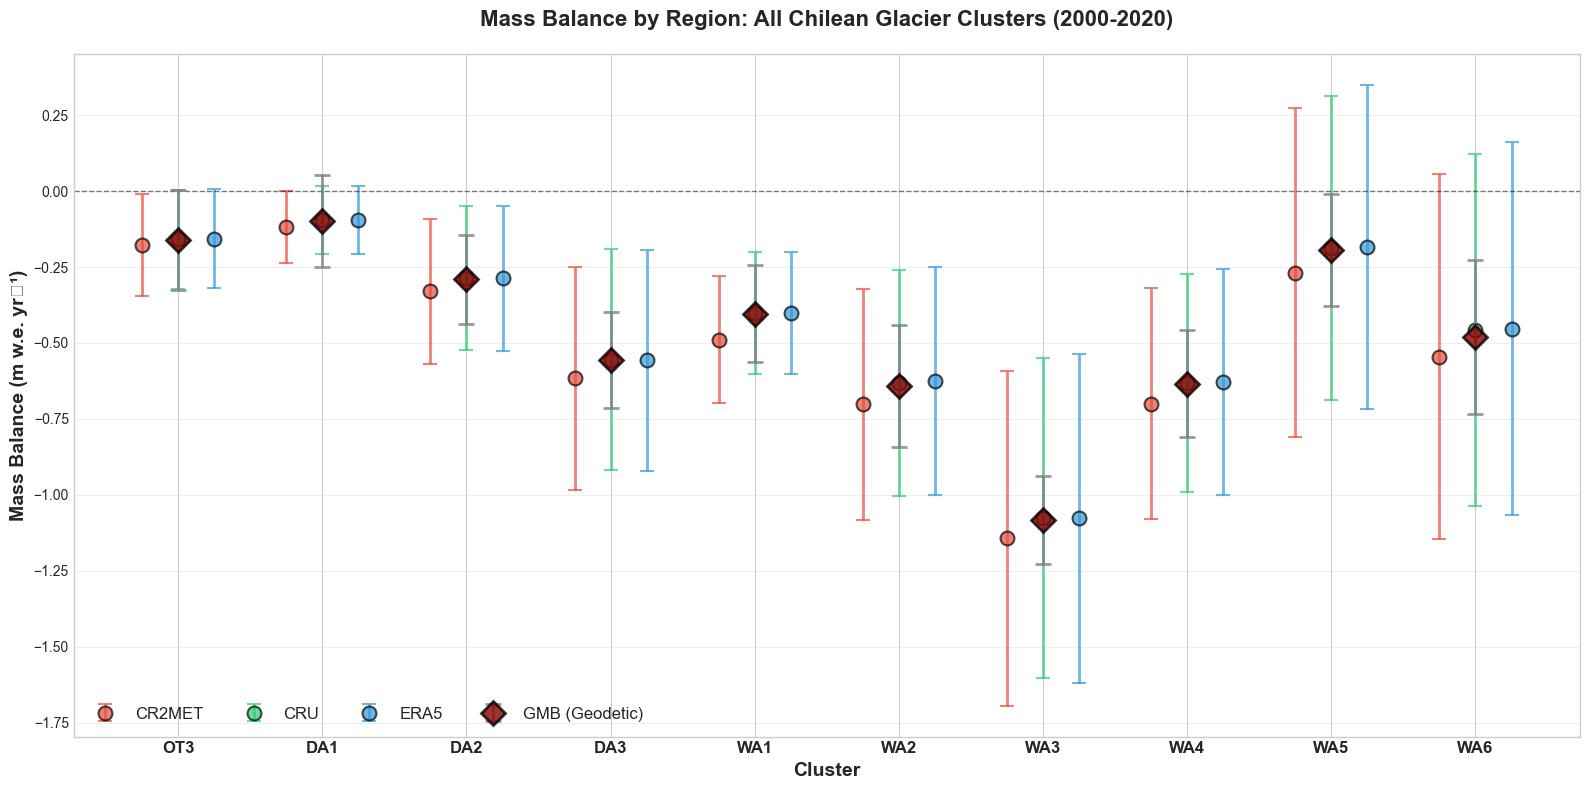

Key observations:
  OT3: GMB=-0.161, SMB range=0.020 m/yr
  DA1: GMB=-0.099, SMB range=0.023 m/yr
  DA2: GMB=-0.290, SMB range=0.044 m/yr
  DA3: GMB=-0.556, SMB range=0.061 m/yr
  WA1: GMB=-0.404, SMB range=0.088 m/yr
  WA2: GMB=-0.642, SMB range=0.077 m/yr
  WA3: GMB=-1.082, SMB range=0.068 m/yr
  WA4: GMB=-0.634, SMB range=0.071 m/yr
  WA5: GMB=-0.194, SMB range=0.084 m/yr
  WA6: GMB=-0.481, SMB range=0.093 m/yr


In [5]:
fig, ax = plt.subplots(figsize=(16, 8))

x_pos = np.arange(len(clusters))
width = 0.25

# Plot each dataset
for i, dataset in enumerate(datasets):
    df_ds = df[df['dataset'] == dataset].sort_values('cluster', 
                key=lambda x: pd.Categorical(x, categories=clusters, ordered=True))
    offset = (i - 1) * width
    
    ax.errorbar(x_pos + offset, df_ds['SMB'], yerr=df_ds['SMB_std'],
               fmt='o', markersize=10, color=colors[dataset],
               capsize=5, capthick=2, linewidth=2, alpha=0.7,
               label=dataset, markeredgecolor='black', markeredgewidth=1.5)

# Add GMB reference
gmb_by_cluster = df[df['dataset'] == 'CR2MET'].sort_values('cluster',
                key=lambda x: pd.Categorical(x, categories=clusters, ordered=True))
ax.errorbar(x_pos, gmb_by_cluster['GMB'], yerr=gmb_by_cluster['GMB_error'],
           fmt='D', markersize=12, color='darkred', markeredgecolor='black',
           markeredgewidth=2, ecolor='gray', capsize=6, capthick=2,
           linewidth=2, label='GMB (Geodetic)', zorder=10, alpha=0.8)

ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_ylabel('Mass Balance (m w.e. yr⁻¹)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=14, fontweight='bold')
ax.set_title('Mass Balance by Region: All Chilean Glacier Clusters (2000-2020)', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(clusters, fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=12, ncol=4)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Key observations:")
for cluster in clusters:
    cluster_data = df[df['cluster'] == cluster]
    smb_range = cluster_data['SMB'].max() - cluster_data['SMB'].min()
    gmb = cluster_data['GMB'].iloc[0]
    print(f"  {cluster}: GMB={gmb:.3f}, SMB range={smb_range:.3f} m/yr")

---
## 3. GMB vs SMB Comparison (Dataset Performance)

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_51069/1565773237.py:39: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/milliespencer/miniconda3/envs/oggm_cr2_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


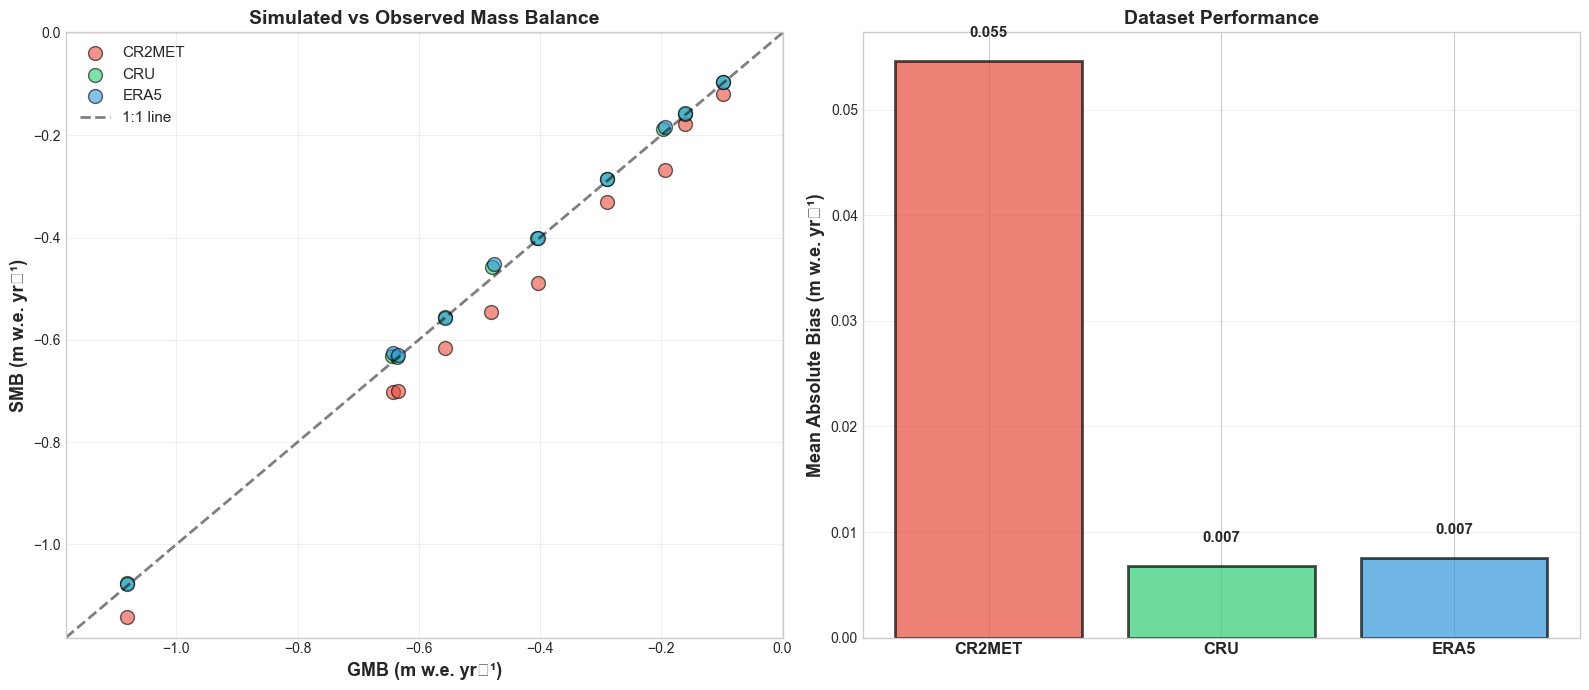


Dataset performance summary:
  CR2MET: RMSE=0.059, R=0.998, Mean|Bias|=0.055 m/yr
  CRU: RMSE=0.009, R=1.000, Mean|Bias|=0.007 m/yr
  ERA5: RMSE=0.010, R=1.000, Mean|Bias|=0.007 m/yr


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: Scatter plot SMB vs GMB
for dataset in datasets:
    df_ds = df[df['dataset'] == dataset]
    ax1.scatter(df_ds['GMB'], df_ds['SMB'], s=100, 
               color=colors[dataset], alpha=0.6, 
               label=dataset, edgecolors='black', linewidth=1)

# 1:1 line
lims = [df['GMB'].min() - 0.1, df['GMB'].max() + 0.1]
ax1.plot(lims, lims, 'k--', linewidth=2, alpha=0.5, label='1:1 line')

ax1.set_xlabel('GMB (m w.e. yr⁻¹)', fontsize=13, fontweight='bold')
ax1.set_ylabel('SMB (m w.e. yr⁻¹)', fontsize=13, fontweight='bold')
ax1.set_title('Simulated vs Observed Mass Balance', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_xlim(lims)
ax1.set_ylim(lims)

# RIGHT: Mean absolute bias by dataset
mean_bias = df.groupby('dataset')['bias'].apply(lambda x: x.abs().mean())
bars = ax2.bar(range(len(datasets)), mean_bias.values, 
              color=[colors[ds] for ds in datasets],
              alpha=0.7, edgecolor='black', linewidth=2)

ax2.set_ylabel('Mean Absolute Bias (m w.e. yr⁻¹)', fontsize=13, fontweight='bold')
ax2.set_title('Dataset Performance', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(datasets)))
ax2.set_xticklabels(datasets, fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, mean_bias.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDataset performance summary:")
for dataset in datasets:
    df_ds = df[df['dataset'] == dataset]
    rmse = np.sqrt((df_ds['bias']**2).mean())
    r = np.corrcoef(df_ds['SMB'], df_ds['GMB'])[0,1]
    print(f"  {dataset}: RMSE={rmse:.3f}, R={r:.3f}, Mean|Bias|={mean_bias[dataset]:.3f} m/yr")

---
## 4. Climate Dataset Comparison

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_51069/924867432.py:74: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/milliespencer/miniconda3/envs/oggm_cr2_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


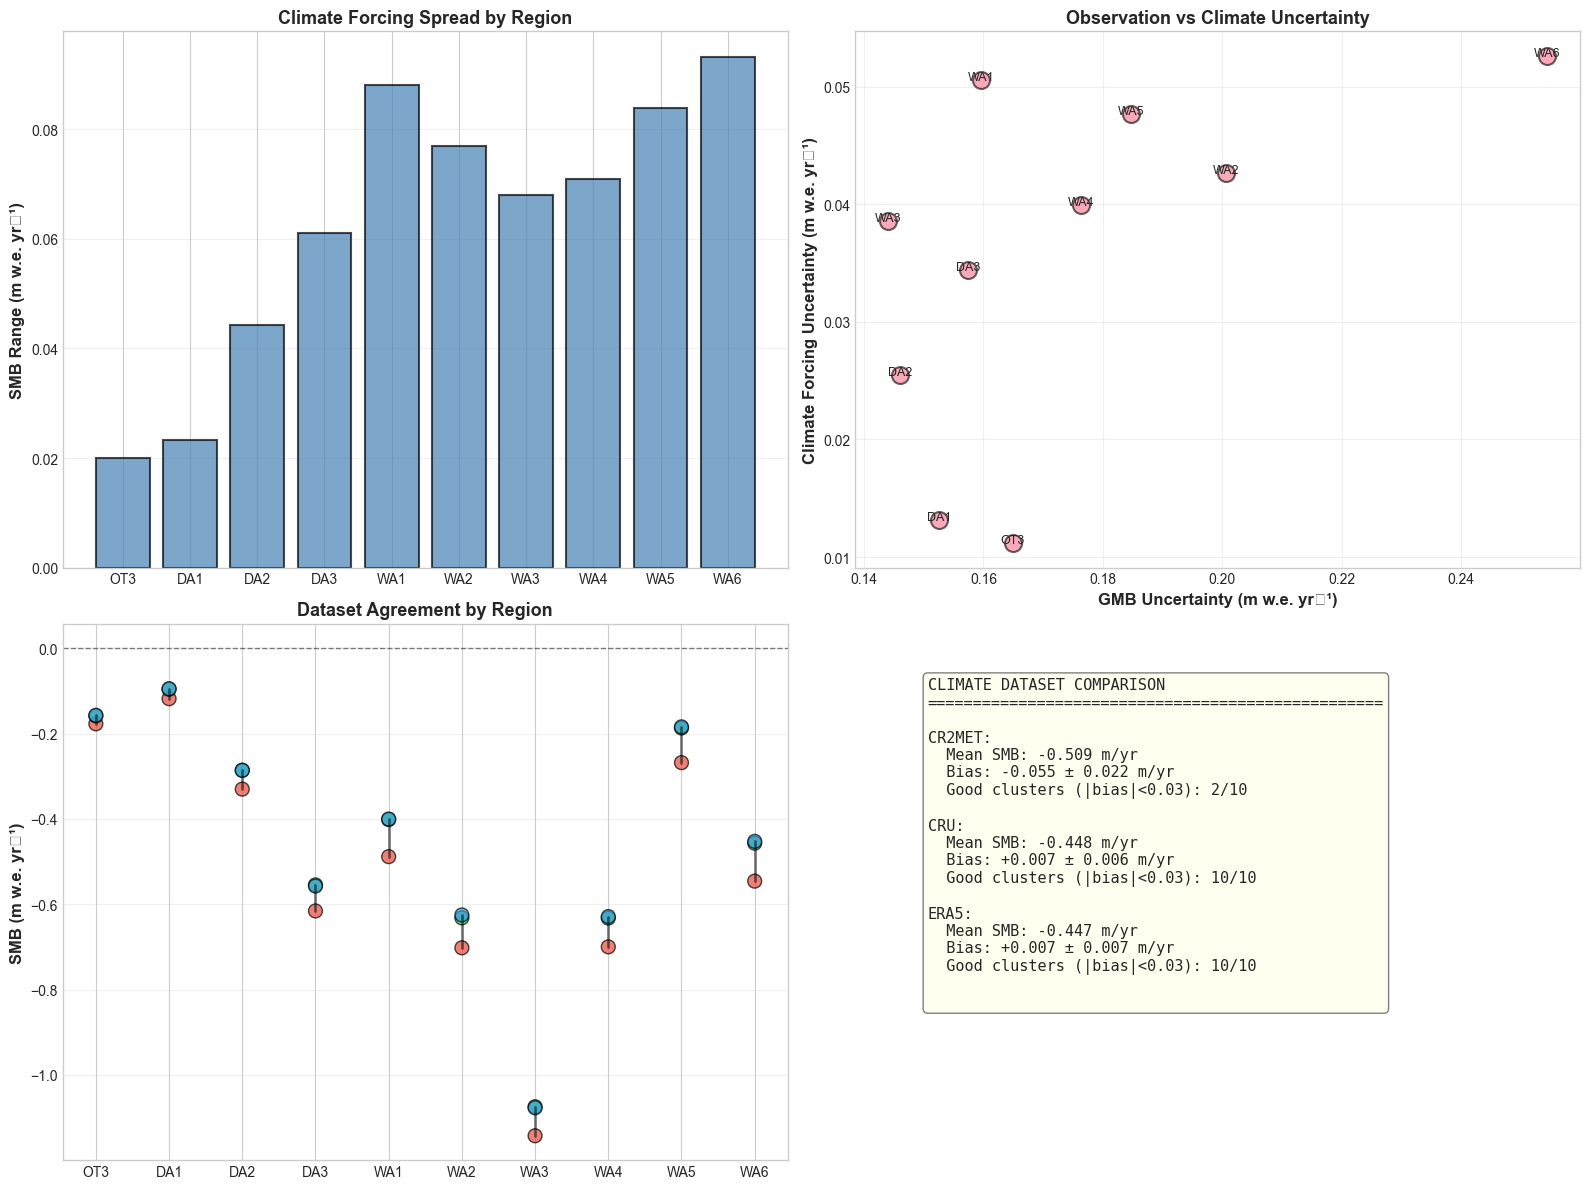

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate statistics by cluster
cluster_stats = []
for cluster in clusters:
    cluster_df = df[df['cluster'] == cluster]
    cluster_stats.append({
        'cluster': cluster,
        'SMB_range': cluster_df['SMB'].max() - cluster_df['SMB'].min(),
        'SMB_mean': cluster_df['SMB'].mean(),
        'climate_uncertainty': cluster_df['SMB'].std(),
        'GMB': cluster_df['GMB'].iloc[0]
    })
stats_df = pd.DataFrame(cluster_stats)

# 1. SMB Range by cluster
ax = axes[0, 0]
x_pos = np.arange(len(clusters))
ax.bar(x_pos, stats_df['SMB_range'], color='steelblue', 
       alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('SMB Range (m w.e. yr⁻¹)', fontsize=12, fontweight='bold')
ax.set_title('Climate Forcing Spread by Region', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(clusters, fontsize=10)
ax.grid(axis='y', alpha=0.3)

# 2. Climate uncertainty vs GMB uncertainty
ax = axes[0, 1]
gmb_unc = df[df['dataset'] == 'CR2MET'].set_index('cluster')['GMB_error']
ax.scatter(gmb_unc, stats_df.set_index('cluster')['climate_uncertainty'], 
          s=150, alpha=0.6, edgecolors='black', linewidth=1.5)
for i, cluster in enumerate(clusters):
    ax.annotate(cluster, 
               (gmb_unc[cluster], stats_df.set_index('cluster').loc[cluster, 'climate_uncertainty']),
               fontsize=9, ha='center')
ax.set_xlabel('GMB Uncertainty (m w.e. yr⁻¹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Climate Forcing Uncertainty (m w.e. yr⁻¹)', fontsize=12, fontweight='bold')
ax.set_title('Observation vs Climate Uncertainty', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# 3. Dataset agreement (variance across datasets)
ax = axes[1, 0]
for i, cluster in enumerate(clusters):
    cluster_df = df[df['cluster'] == cluster]
    smb_vals = cluster_df['SMB'].values
    ax.scatter([i]*len(smb_vals), smb_vals, s=100, 
              color=[colors[ds] for ds in cluster_df['dataset']], 
              alpha=0.7, edgecolors='black', linewidth=1)
    ax.plot([i, i], [smb_vals.min(), smb_vals.max()], 
           'k-', linewidth=2, alpha=0.5)

ax.set_ylabel('SMB (m w.e. yr⁻¹)', fontsize=12, fontweight='bold')
ax.set_title('Dataset Agreement by Region', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(clusters)))
ax.set_xticklabels(clusters, fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)

# 4. Summary statistics table
ax = axes[1, 1]
ax.axis('off')
summary_text = "CLIMATE DATASET COMPARISON\n" + "="*50 + "\n\n"
for dataset in datasets:
    df_ds = df[df['dataset'] == dataset]
    summary_text += f"{dataset}:\n"
    summary_text += f"  Mean SMB: {df_ds['SMB'].mean():.3f} m/yr\n"
    summary_text += f"  Bias: {df_ds['bias'].mean():+.3f} ± {df_ds['bias'].std():.3f} m/yr\n"
    summary_text += f"  Good clusters (|bias|<0.03): {len(df_ds[df_ds['bias'].abs() < 0.03])}/10\n\n"

ax.text(0.1, 0.9, summary_text, fontsize=11, family='monospace',
       verticalalignment='top', transform=ax.transAxes,
       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.show()

---
# WA1 Detailed Analysis
## Mass Balance Range, Temporal Evolution, and Runoff

### 5a. WA1 Mass Balance Range and Statistics

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_51069/451070660.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, labels=datasets, patch_artist=True,
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_51069/451070660.py:63: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/milliespencer/miniconda3/envs/oggm_cr2_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


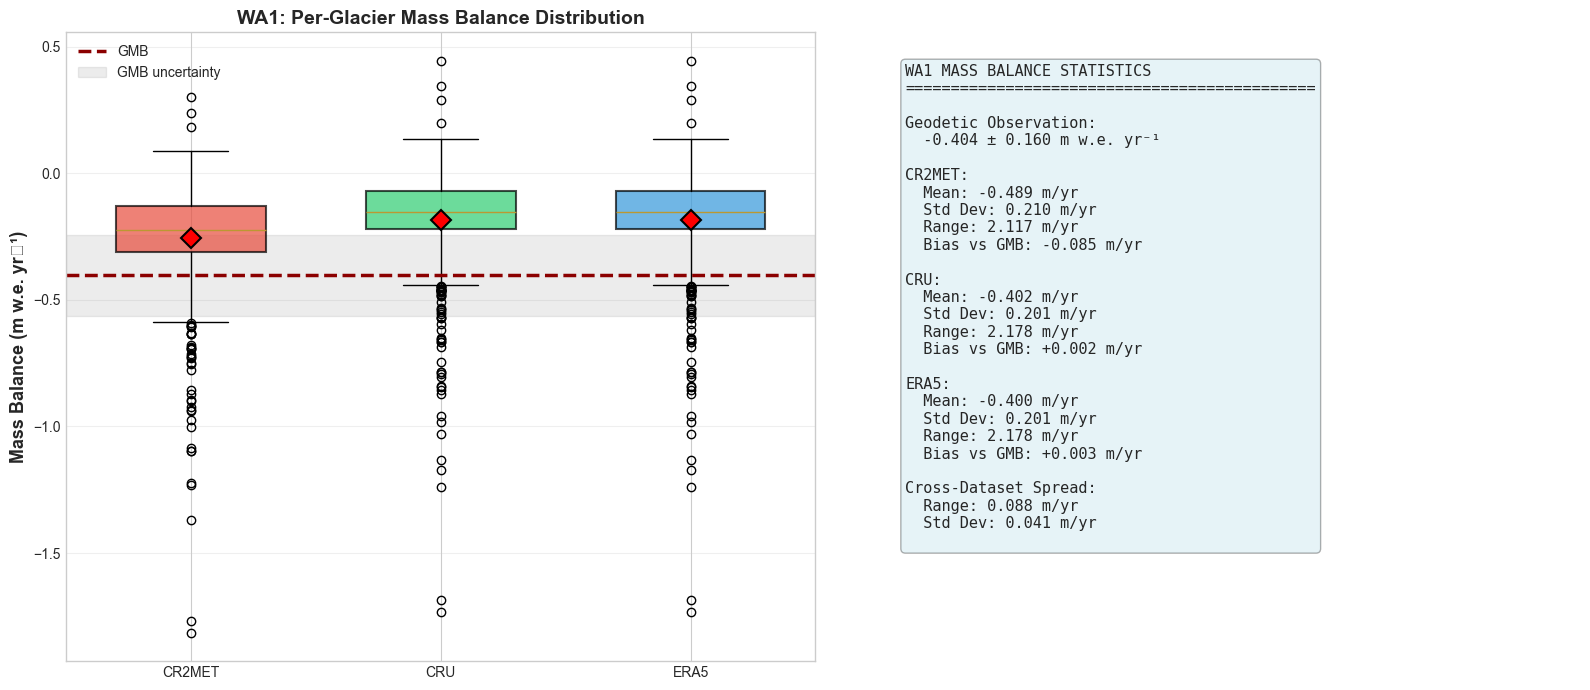

✓ WA1 mass balance statistics displayed


In [8]:
# Load WA1 per-glacier data
wa1_glacier_data = {}
for dataset in datasets:
    mb_file = f'{base_path}{dataset}/WA1/mb.csv'
    if os.path.exists(mb_file):
        mb_df = pd.read_csv(mb_file)
        glacier_means = mb_df.select_dtypes(include=[np.number]).mean(axis=1) / 1000  # Convert to m
        wa1_glacier_data[dataset] = glacier_means

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: Box plot of per-glacier mass balance
box_data = [wa1_glacier_data[ds].values for ds in datasets]
bp = ax1.boxplot(box_data, labels=datasets, patch_artist=True,
                showmeans=True, widths=0.6,
                meanprops=dict(marker='D', markerfacecolor='red', 
                             markersize=10, markeredgecolor='black', 
                             markeredgewidth=1.5))

for patch, dataset in zip(bp['boxes'], datasets):
    patch.set_facecolor(colors[dataset])
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Add GMB reference
wa1_gmb = df[(df['cluster'] == 'WA1') & (df['dataset'] == 'CR2MET')]['GMB'].iloc[0]
wa1_gmb_err = df[(df['cluster'] == 'WA1') & (df['dataset'] == 'CR2MET')]['GMB_error'].iloc[0]
ax1.axhline(y=wa1_gmb, color='darkred', linestyle='--', linewidth=2.5, label='GMB')
ax1.axhspan(wa1_gmb - wa1_gmb_err, wa1_gmb + wa1_gmb_err, 
           alpha=0.15, color='gray', label='GMB uncertainty')

ax1.set_ylabel('Mass Balance (m w.e. yr⁻¹)', fontsize=13, fontweight='bold')
ax1.set_title('WA1: Per-Glacier Mass Balance Distribution', 
             fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# RIGHT: Summary statistics
ax2.axis('off')
wa1_text = "WA1 MASS BALANCE STATISTICS\n" + "="*45 + "\n\n"
wa1_text += f"Geodetic Observation:\n  {wa1_gmb:.3f} ± {wa1_gmb_err:.3f} m w.e. yr⁻¹\n\n"

for dataset in datasets:
    data = wa1_glacier_data[dataset]
    wa1_smb = df[(df['cluster'] == 'WA1') & (df['dataset'] == dataset)]['SMB'].iloc[0]
    wa1_text += f"{dataset}:\n"
    wa1_text += f"  Mean: {wa1_smb:.3f} m/yr\n"
    wa1_text += f"  Std Dev: {data.std():.3f} m/yr\n"
    wa1_text += f"  Range: {data.max() - data.min():.3f} m/yr\n"
    wa1_text += f"  Bias vs GMB: {wa1_smb - wa1_gmb:+.3f} m/yr\n\n"

# Cross-dataset statistics
wa1_all_smb = df[df['cluster'] == 'WA1']['SMB'].values
wa1_text += f"Cross-Dataset Spread:\n"
wa1_text += f"  Range: {wa1_all_smb.max() - wa1_all_smb.min():.3f} m/yr\n"
wa1_text += f"  Std Dev: {wa1_all_smb.std():.3f} m/yr\n"

ax2.text(0.1, 0.95, wa1_text, fontsize=11, family='monospace',
        verticalalignment='top', transform=ax2.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.show()

print("✓ WA1 mass balance statistics displayed")

### 5b. WA1 Annual Mass Balance Timeseries

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_51069/4135978435.py:42: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/milliespencer/miniconda3/envs/oggm_cr2_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


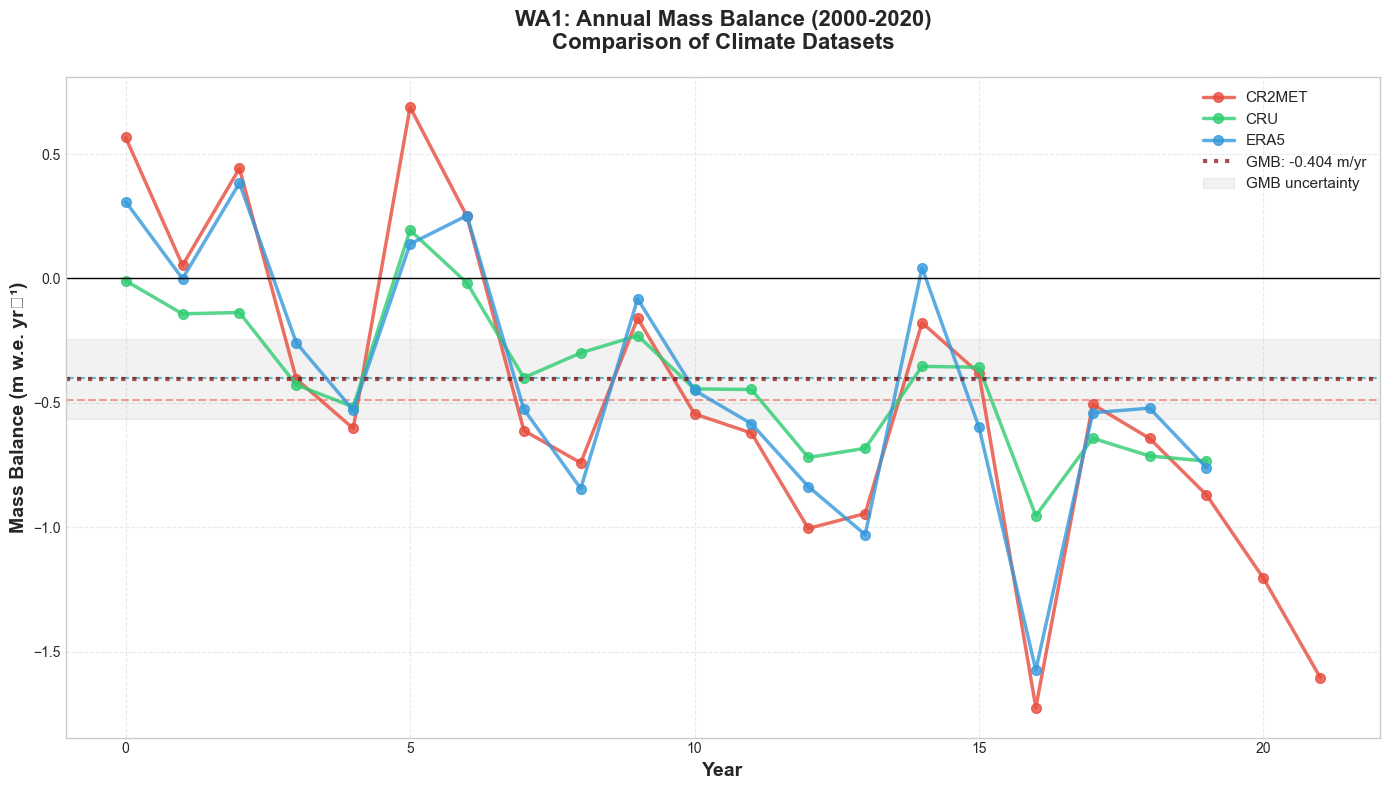

Year-to-year variability:
  CR2MET: 0.635 m/yr
  CRU: 0.291 m/yr
  ERA5: 0.500 m/yr


In [9]:
# Load annual timeseries
wa1_annual = {}
for dataset in datasets:
    ts_file = f'{base_path}{dataset}/WA1/mb_promedio.csv'
    if os.path.exists(ts_file):
        df_ts = pd.read_csv(ts_file)
        # Get the mass balance column (usually second column)
        mb_col = df_ts.columns[1]
        wa1_annual[dataset] = df_ts[[df_ts.columns[0], mb_col]].copy()
        wa1_annual[dataset].columns = ['year', 'mb']
        wa1_annual[dataset]['mb'] = wa1_annual[dataset]['mb'] / 1000  # Convert to m

fig, ax = plt.subplots(figsize=(14, 8))

# Plot timeseries
for dataset in datasets:
    if dataset in wa1_annual:
        df_ts = wa1_annual[dataset]
        ax.plot(df_ts['year'], df_ts['mb'], 'o-', 
               color=colors[dataset], linewidth=2.5, markersize=7,
               label=dataset, alpha=0.8)
        
        # Add mean line
        mean_mb = df_ts['mb'].mean()
        ax.axhline(y=mean_mb, color=colors[dataset], linestyle='--',
                  linewidth=1.5, alpha=0.5)

# Add GMB reference
ax.axhline(y=wa1_gmb, color='darkred', linestyle=':', linewidth=3,
          label=f'GMB: {wa1_gmb:.3f} m/yr', alpha=0.7)
ax.axhspan(wa1_gmb - wa1_gmb_err, wa1_gmb + wa1_gmb_err,
          alpha=0.1, color='gray', label='GMB uncertainty')

ax.set_xlabel('Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Mass Balance (m w.e. yr⁻¹)', fontsize=14, fontweight='bold')
ax.set_title('WA1: Annual Mass Balance (2000-2020)\nComparison of Climate Datasets',
            fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.4, linestyle='--')
ax.axhline(y=0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

print("Year-to-year variability:")
for dataset in datasets:
    if dataset in wa1_annual:
        std = wa1_annual[dataset]['mb'].std()
        print(f"  {dataset}: {std:.3f} m/yr")

### 5c. WA1 Runoff Analysis

✓ Extracted 288 months for CR2MET
✓ Extracted 264 months for CRU
✓ Extracted 264 months for ERA5


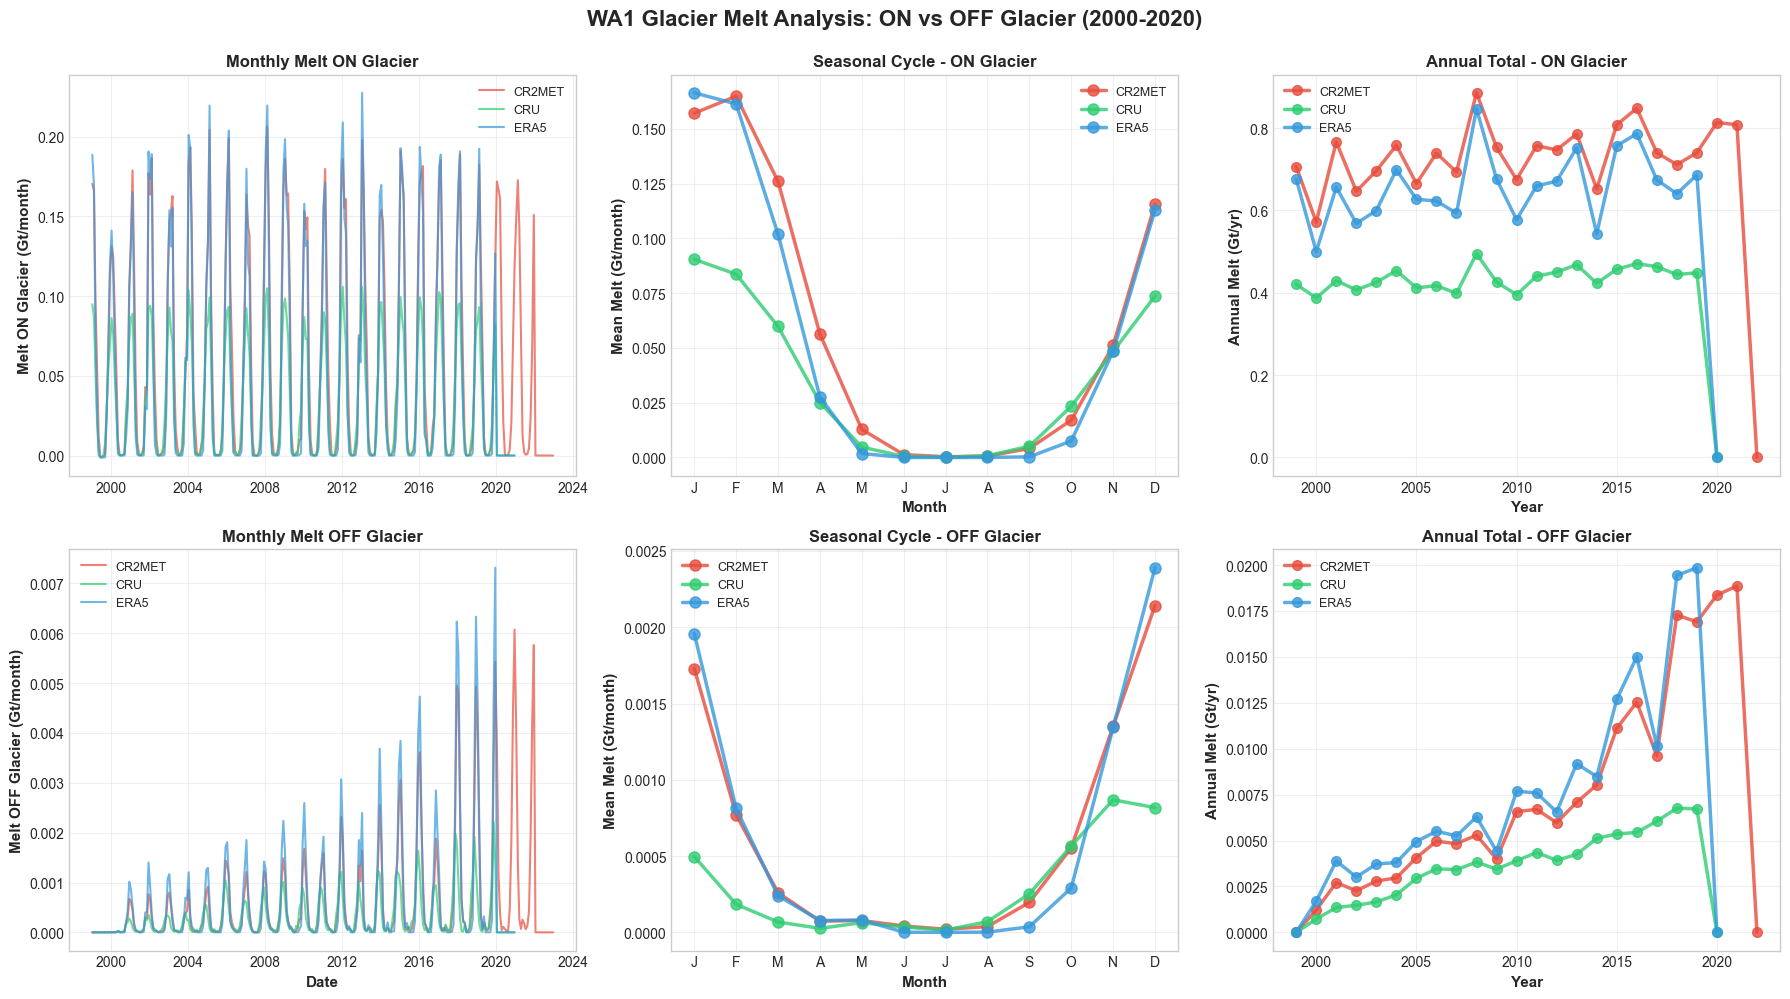


WA1 Glacier Melt Summary (2000-2020):
  CR2MET:
    Total melt ON glacier:  16.97 Gt (99.0%)
    Total melt OFF glacier: 0.17 Gt (1.0%)
    Mean annual ON:  0.71 Gt/yr
    Mean annual OFF: 0.01 Gt/yr
    Peak melt month: F

  CRU:
    Total melt ON glacier:  9.13 Gt (99.2%)
    Total melt OFF glacier: 0.08 Gt (0.8%)
    Mean annual ON:  0.42 Gt/yr
    Mean annual OFF: 0.00 Gt/yr
    Peak melt month: J

  ERA5:
    Total melt ON glacier:  13.81 Gt (98.9%)
    Total melt OFF glacier: 0.16 Gt (1.1%)
    Mean annual ON:  0.63 Gt/yr
    Mean annual OFF: 0.01 Gt/yr
    Peak melt month: J



In [13]:
### 5c. WA1 Glacier Melt Analysis

# Load NetCDF files for WA1
wa1_nc = {}
for dataset in datasets:
    nc_file = f'{base_path}{dataset}/WA1/run_output_2000_2019_hydro_{"TC" if dataset=="CR2MET" else dataset}_WA1.nc'
    if os.path.exists(nc_file):
        wa1_nc[dataset] = xr.open_dataset(nc_file)

def extract_monthly_melt(nc_dataset, dataset_name):
    """Extract monthly glacier melt from NetCDF"""
    # Check what's available
    if 'melt_on_glacier_monthly' not in nc_dataset or 'melt_off_glacier_monthly' not in nc_dataset:
        print(f"  Warning: No melt data found for {dataset_name}")
        return None
    
    # Extract melt on and off glacier (sum across all glaciers)
    melt_on = nc_dataset['melt_on_glacier_monthly'].sum(dim='rgi_id')
    melt_off = nc_dataset['melt_off_glacier_monthly'].sum(dim='rgi_id')
    
    # Build monthly DataFrame
    monthly_data = []
    years = nc_dataset['time'].values
    n_months = melt_on.shape[1]  # Should be 12
    
    for i, year in enumerate(years):
        for month in range(n_months):
            try:
                melt_on_val = float(melt_on.isel(time=i, month_2d=month).values) / 1e12  # Convert kg to Gt
                melt_off_val = float(melt_off.isel(time=i, month_2d=month).values) / 1e12
                monthly_data.append({
                    'date': pd.Timestamp(year=int(year), month=month+1, day=15),
                    'year': int(year),
                    'month': month+1,
                    'melt_on_Gt': melt_on_val,
                    'melt_off_Gt': melt_off_val,
                    'melt_total_Gt': melt_on_val + melt_off_val
                })
            except:
                continue
    
    return pd.DataFrame(monthly_data) if monthly_data else None

# Extract monthly melt data
wa1_monthly = {}
for dataset in datasets:
    if dataset in wa1_nc:
        monthly = extract_monthly_melt(wa1_nc[dataset], dataset)
        if monthly is not None:
            wa1_monthly[dataset] = monthly
            print(f"✓ Extracted {len(monthly)} months for {dataset}")

if len(wa1_monthly) > 0:
    # Create melt plots (2 rows x 3 columns)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
    
    # ============================================
    # TOP ROW: MELT ON GLACIER
    # ============================================
    
    # 1. Monthly melt ON glacier timeseries
    ax = axes[0, 0]
    for dataset in datasets:
        if dataset in wa1_monthly:
            df_m = wa1_monthly[dataset]
            ax.plot(df_m['date'], df_m['melt_on_Gt'], '-',
                   color=colors[dataset], linewidth=1.5,
                   label=dataset, alpha=0.7)
    
    ax.set_ylabel('Melt ON Glacier (Gt/month)', fontsize=11, fontweight='bold')
    ax.set_title('Monthly Melt ON Glacier', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # 2. Seasonal cycle ON glacier
    ax = axes[0, 1]
    for dataset in datasets:
        if dataset in wa1_monthly:
            seasonal = wa1_monthly[dataset].groupby('month')['melt_on_Gt'].mean()
            ax.plot(range(1, 13), seasonal, 'o-',
                   color=colors[dataset], linewidth=2.5, markersize=8,
                   label=dataset, alpha=0.8)
    
    ax.set_xlabel('Month', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Melt (Gt/month)', fontsize=11, fontweight='bold')
    ax.set_title('Seasonal Cycle - ON Glacier', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # 3. Annual totals ON glacier
    ax = axes[0, 2]
    for dataset in datasets:
        if dataset in wa1_monthly:
            annual = wa1_monthly[dataset].groupby('year')['melt_on_Gt'].sum()
            ax.plot(annual.index, annual.values, 'o-',
                   color=colors[dataset], linewidth=2.5, markersize=7,
                   label=dataset, alpha=0.8)
    
    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.set_ylabel('Annual Melt (Gt/yr)', fontsize=11, fontweight='bold')
    ax.set_title('Annual Total - ON Glacier', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # ============================================
    # BOTTOM ROW: MELT OFF GLACIER
    # ============================================
    
    # 4. Monthly melt OFF glacier timeseries
    ax = axes[1, 0]
    for dataset in datasets:
        if dataset in wa1_monthly:
            df_m = wa1_monthly[dataset]
            ax.plot(df_m['date'], df_m['melt_off_Gt'], '-',
                   color=colors[dataset], linewidth=1.5,
                   label=dataset, alpha=0.7)
    
    ax.set_xlabel('Date', fontsize=11, fontweight='bold')
    ax.set_ylabel('Melt OFF Glacier (Gt/month)', fontsize=11, fontweight='bold')
    ax.set_title('Monthly Melt OFF Glacier', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # 5. Seasonal cycle OFF glacier
    ax = axes[1, 1]
    for dataset in datasets:
        if dataset in wa1_monthly:
            seasonal = wa1_monthly[dataset].groupby('month')['melt_off_Gt'].mean()
            ax.plot(range(1, 13), seasonal, 'o-',
                   color=colors[dataset], linewidth=2.5, markersize=8,
                   label=dataset, alpha=0.8)
    
    ax.set_xlabel('Month', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Melt (Gt/month)', fontsize=11, fontweight='bold')
    ax.set_title('Seasonal Cycle - OFF Glacier', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # 6. Annual totals OFF glacier
    ax = axes[1, 2]
    for dataset in datasets:
        if dataset in wa1_monthly:
            annual = wa1_monthly[dataset].groupby('year')['melt_off_Gt'].sum()
            ax.plot(annual.index, annual.values, 'o-',
                   color=colors[dataset], linewidth=2.5, markersize=7,
                   label=dataset, alpha=0.8)
    
    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.set_ylabel('Annual Melt (Gt/yr)', fontsize=11, fontweight='bold')
    ax.set_title('Annual Total - OFF Glacier', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.suptitle('WA1 Glacier Melt Analysis: ON vs OFF Glacier (2000-2020)', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nWA1 Glacier Melt Summary (2000-2020):")
    for dataset in datasets:
        if dataset in wa1_monthly:
            total_on = wa1_monthly[dataset]['melt_on_Gt'].sum()
            total_off = wa1_monthly[dataset]['melt_off_Gt'].sum()
            total = total_on + total_off
            pct_on = (total_on / total) * 100
            mean_annual_on = wa1_monthly[dataset].groupby('year')['melt_on_Gt'].sum().mean()
            mean_annual_off = wa1_monthly[dataset].groupby('year')['melt_off_Gt'].sum().mean()
            peak_month = wa1_monthly[dataset].groupby('month')['melt_total_Gt'].mean().idxmax()
            print(f"  {dataset}:")
            print(f"    Total melt ON glacier:  {total_on:.2f} Gt ({pct_on:.1f}%)")
            print(f"    Total melt OFF glacier: {total_off:.2f} Gt ({100-pct_on:.1f}%)")
            print(f"    Mean annual ON:  {mean_annual_on:.2f} Gt/yr")
            print(f"    Mean annual OFF: {mean_annual_off:.2f} Gt/yr")
            print(f"    Peak melt month: {months[peak_month-1]}\n")
else:
    print("⚠ No monthly melt data available for WA1")

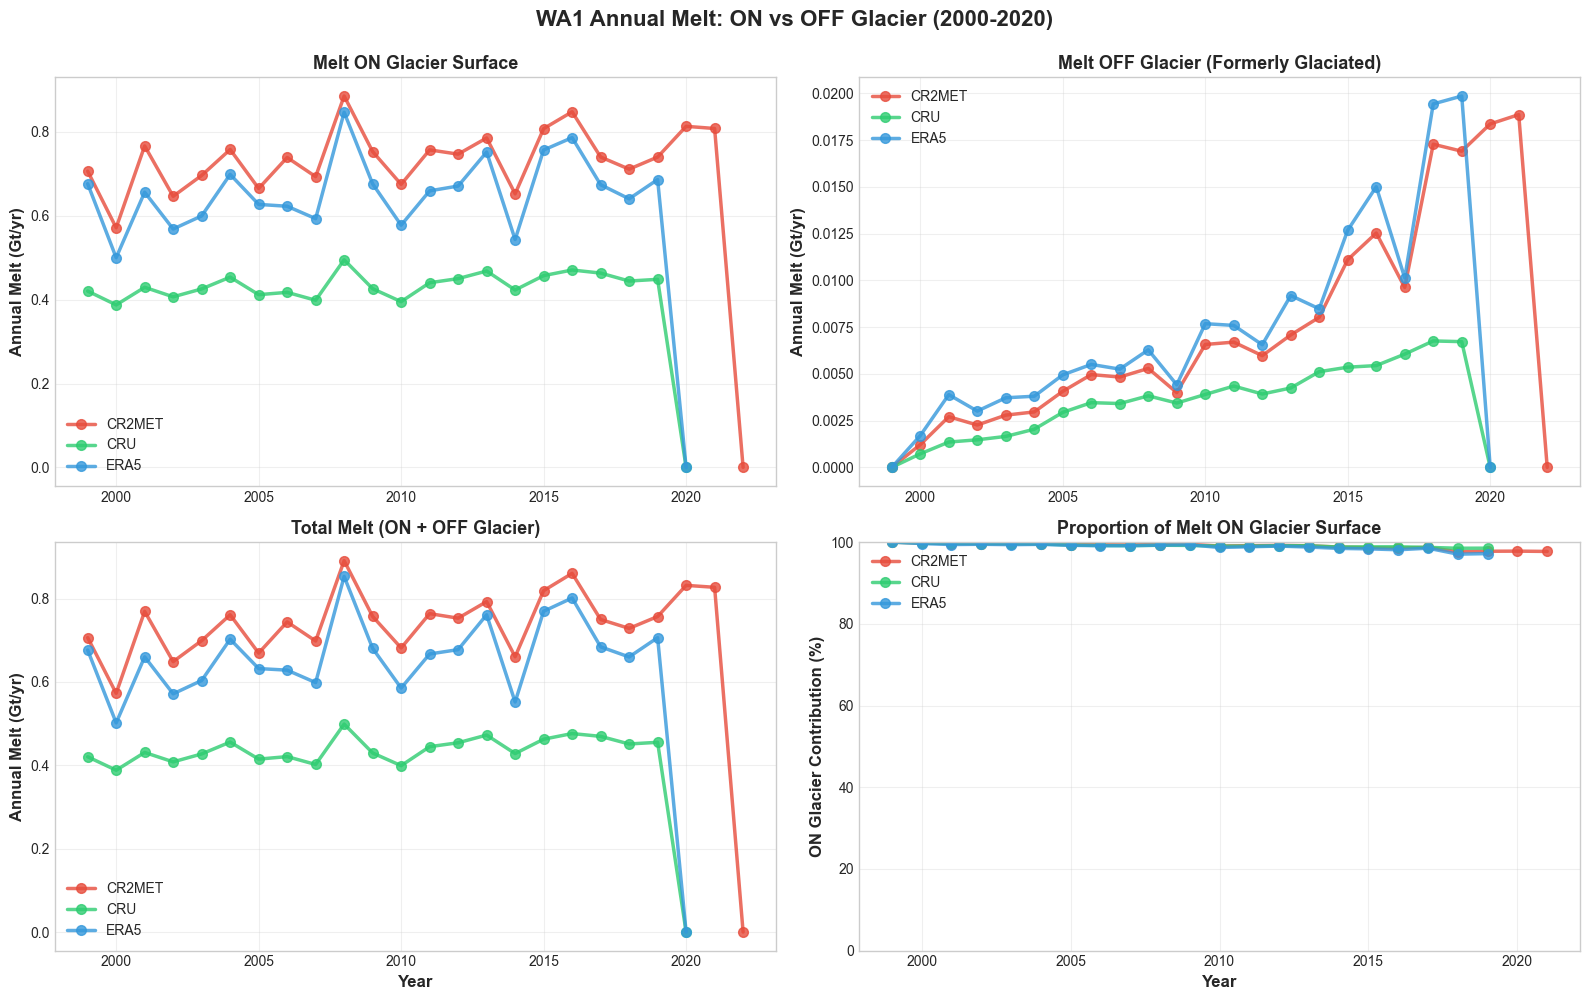


WA1 Annual Melt Summary:
  CR2MET:
    Mean annual ON:  0.71 Gt/yr (99.0%)
    Mean annual OFF: 0.01 Gt/yr (1.0%)
    Mean total:      0.71 Gt/yr
  CRU:
    Mean annual ON:  0.42 Gt/yr (99.2%)
    Mean annual OFF: 0.00 Gt/yr (0.8%)
    Mean total:      0.42 Gt/yr
  ERA5:
    Mean annual ON:  0.63 Gt/yr (98.9%)
    Mean annual OFF: 0.01 Gt/yr (1.1%)
    Mean total:      0.64 Gt/yr


In [14]:
### 5d. WA1 Total Melt: ON vs OFF Glacier (Annual)

if len(wa1_nc) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Extract annual melt totals
    wa1_annual_melt = {}
    for dataset in datasets:
        if dataset in wa1_nc:
            nc = wa1_nc[dataset]
            
            # Sum across all glaciers and all months for each year
            if 'melt_on_glacier_monthly' in nc and 'melt_off_glacier_monthly' in nc:
                melt_on = nc['melt_on_glacier_monthly'].sum(dim='rgi_id').sum(dim='month_2d') / 1e12  # Gt/yr
                melt_off = nc['melt_off_glacier_monthly'].sum(dim='rgi_id').sum(dim='month_2d') / 1e12
                
                years = nc['time'].values
                wa1_annual_melt[dataset] = pd.DataFrame({
                    'year': years,
                    'melt_on_Gt': melt_on.values,
                    'melt_off_Gt': melt_off.values,
                    'melt_total_Gt': melt_on.values + melt_off.values
                })
    
    if len(wa1_annual_melt) > 0:
        # 1. Melt ON glacier
        ax = axes[0, 0]
        for dataset in datasets:
            if dataset in wa1_annual_melt:
                df = wa1_annual_melt[dataset]
                ax.plot(df['year'], df['melt_on_Gt'], 'o-',
                       color=colors[dataset], linewidth=2.5, markersize=7,
                       label=dataset, alpha=0.8)
        
        ax.set_ylabel('Annual Melt (Gt/yr)', fontsize=12, fontweight='bold')
        ax.set_title('Melt ON Glacier Surface', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
        
        # 2. Melt OFF glacier
        ax = axes[0, 1]
        for dataset in datasets:
            if dataset in wa1_annual_melt:
                df = wa1_annual_melt[dataset]
                ax.plot(df['year'], df['melt_off_Gt'], 'o-',
                       color=colors[dataset], linewidth=2.5, markersize=7,
                       label=dataset, alpha=0.8)
        
        ax.set_ylabel('Annual Melt (Gt/yr)', fontsize=12, fontweight='bold')
        ax.set_title('Melt OFF Glacier (Formerly Glaciated)', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
        
        # 3. Total melt (ON + OFF)
        ax = axes[1, 0]
        for dataset in datasets:
            if dataset in wa1_annual_melt:
                df = wa1_annual_melt[dataset]
                ax.plot(df['year'], df['melt_total_Gt'], 'o-',
                       color=colors[dataset], linewidth=2.5, markersize=7,
                       label=dataset, alpha=0.8)
        
        ax.set_xlabel('Year', fontsize=12, fontweight='bold')
        ax.set_ylabel('Annual Melt (Gt/yr)', fontsize=12, fontweight='bold')
        ax.set_title('Total Melt (ON + OFF Glacier)', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
        
        # 4. ON vs OFF contribution (%)
        ax = axes[1, 1]
        for dataset in datasets:
            if dataset in wa1_annual_melt:
                df = wa1_annual_melt[dataset]
                pct_on = (df['melt_on_Gt'] / df['melt_total_Gt']) * 100
                ax.plot(df['year'], pct_on, 'o-',
                       color=colors[dataset], linewidth=2.5, markersize=7,
                       label=dataset, alpha=0.8)
        
        ax.set_xlabel('Year', fontsize=12, fontweight='bold')
        ax.set_ylabel('ON Glacier Contribution (%)', fontsize=12, fontweight='bold')
        ax.set_title('Proportion of Melt ON Glacier Surface', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
        ax.set_ylim([0, 100])
        
        plt.suptitle('WA1 Annual Melt: ON vs OFF Glacier (2000-2020)', 
                    fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        plt.show()
        
        # Print summary
        print("\nWA1 Annual Melt Summary:")
        for dataset in datasets:
            if dataset in wa1_annual_melt:
                df = wa1_annual_melt[dataset]
                mean_on = df['melt_on_Gt'].mean()
                mean_off = df['melt_off_Gt'].mean()
                mean_total = df['melt_total_Gt'].mean()
                pct_on = (mean_on / mean_total) * 100
                print(f"  {dataset}:")
                print(f"    Mean annual ON:  {mean_on:.2f} Gt/yr ({pct_on:.1f}%)")
                print(f"    Mean annual OFF: {mean_off:.2f} Gt/yr ({100-pct_on:.1f}%)")
                print(f"    Mean total:      {mean_total:.2f} Gt/yr")
    else:
        print("⚠ No annual melt data available")
else:
    print("⚠ NetCDF files not loaded")

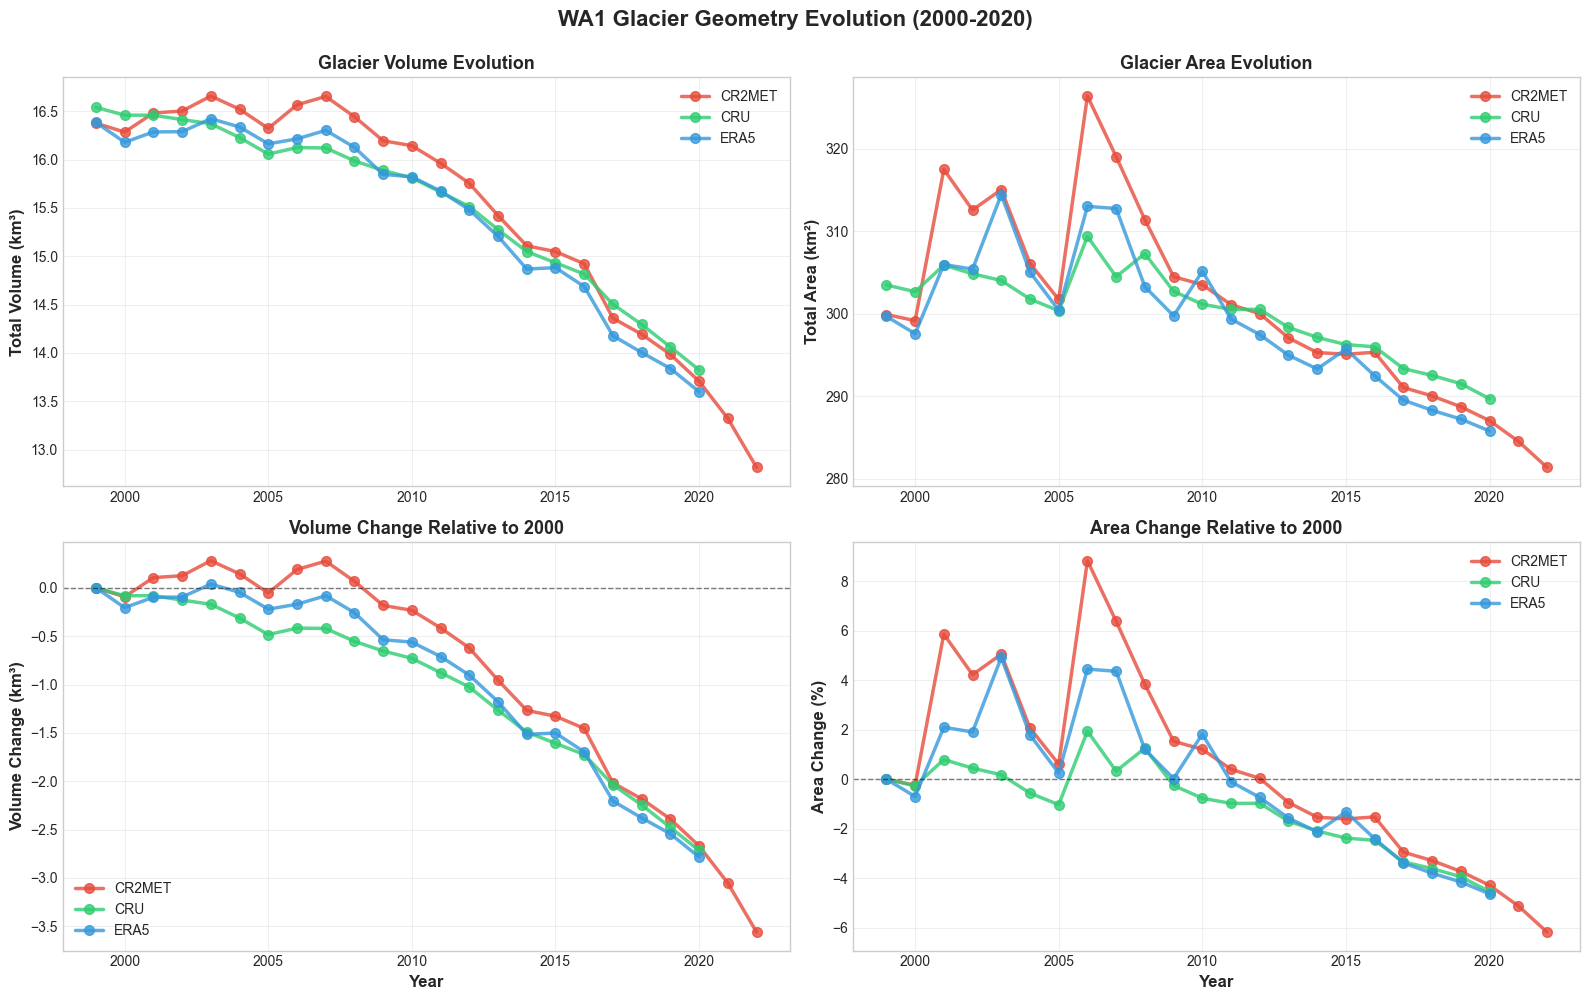


WA1 Geometry Change Summary (2000-2020):
  CR2MET:
    Volume loss: 3.56 km³ (21.7%)
    Area loss:   18.53 km² (6.2%)
    Initial volume: 16.38 km³
    Final volume:   12.82 km³
  CRU:
    Volume loss: 2.72 km³ (16.4%)
    Area loss:   13.80 km² (4.5%)
    Initial volume: 16.54 km³
    Final volume:   13.82 km³
  ERA5:
    Volume loss: 2.78 km³ (17.0%)
    Area loss:   13.90 km² (4.6%)
    Initial volume: 16.38 km³
    Final volume:   13.60 km³


In [15]:
### 5e. WA1 Glacier Geometry Evolution: Volume and Area

if len(wa1_nc) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Extract volume and area
    wa1_geometry = {}
    for dataset in datasets:
        if dataset in wa1_nc:
            nc = wa1_nc[dataset]
            
            # Sum across all glaciers
            total_volume = nc['volume'].sum(dim='rgi_id') / 1e9  # Convert m³ to km³
            total_area = nc['area'].sum(dim='rgi_id') / 1e6      # Convert m² to km²
            
            years = nc['time'].values
            wa1_geometry[dataset] = pd.DataFrame({
                'year': years,
                'volume_km3': total_volume.values,
                'area_km2': total_area.values
            })
    
    if len(wa1_geometry) > 0:
        # 1. Total volume evolution
        ax = axes[0, 0]
        for dataset in datasets:
            if dataset in wa1_geometry:
                df = wa1_geometry[dataset]
                ax.plot(df['year'], df['volume_km3'], 'o-',
                       color=colors[dataset], linewidth=2.5, markersize=7,
                       label=dataset, alpha=0.8)
        
        ax.set_ylabel('Total Volume (km³)', fontsize=12, fontweight='bold')
        ax.set_title('Glacier Volume Evolution', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
        
        # 2. Total area evolution
        ax = axes[0, 1]
        for dataset in datasets:
            if dataset in wa1_geometry:
                df = wa1_geometry[dataset]
                ax.plot(df['year'], df['area_km2'], 'o-',
                       color=colors[dataset], linewidth=2.5, markersize=7,
                       label=dataset, alpha=0.8)
        
        ax.set_ylabel('Total Area (km²)', fontsize=12, fontweight='bold')
        ax.set_title('Glacier Area Evolution', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
        
        # 3. Volume change (relative to 2000)
        ax = axes[1, 0]
        for dataset in datasets:
            if dataset in wa1_geometry:
                df = wa1_geometry[dataset]
                vol_change = df['volume_km3'] - df['volume_km3'].iloc[0]
                ax.plot(df['year'], vol_change, 'o-',
                       color=colors[dataset], linewidth=2.5, markersize=7,
                       label=dataset, alpha=0.8)
        
        ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
        ax.set_xlabel('Year', fontsize=12, fontweight='bold')
        ax.set_ylabel('Volume Change (km³)', fontsize=12, fontweight='bold')
        ax.set_title('Volume Change Relative to 2000', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
        
        # 4. Area change (relative to 2000, in %)
        ax = axes[1, 1]
        for dataset in datasets:
            if dataset in wa1_geometry:
                df = wa1_geometry[dataset]
                area_change_pct = ((df['area_km2'] - df['area_km2'].iloc[0]) / 
                                  df['area_km2'].iloc[0] * 100)
                ax.plot(df['year'], area_change_pct, 'o-',
                       color=colors[dataset], linewidth=2.5, markersize=7,
                       label=dataset, alpha=0.8)
        
        ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
        ax.set_xlabel('Year', fontsize=12, fontweight='bold')
        ax.set_ylabel('Area Change (%)', fontsize=12, fontweight='bold')
        ax.set_title('Area Change Relative to 2000', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
        
        plt.suptitle('WA1 Glacier Geometry Evolution (2000-2020)', 
                    fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        plt.show()
        
        # Print summary
        print("\nWA1 Geometry Change Summary (2000-2020):")
        for dataset in datasets:
            if dataset in wa1_geometry:
                df = wa1_geometry[dataset]
                vol_loss = df['volume_km3'].iloc[0] - df['volume_km3'].iloc[-1]
                vol_pct = (vol_loss / df['volume_km3'].iloc[0]) * 100
                area_loss = df['area_km2'].iloc[0] - df['area_km2'].iloc[-1]
                area_pct = (area_loss / df['area_km2'].iloc[0]) * 100
                print(f"  {dataset}:")
                print(f"    Volume loss: {vol_loss:.2f} km³ ({vol_pct:.1f}%)")
                print(f"    Area loss:   {area_loss:.2f} km² ({area_pct:.1f}%)")
                print(f"    Initial volume: {df['volume_km3'].iloc[0]:.2f} km³")
                print(f"    Final volume:   {df['volume_km3'].iloc[-1]:.2f} km³")
    else:
        print("⚠ No geometry data available")
else:
    print("⚠ NetCDF files not loaded")

---
## Summary and Conclusions

In [11]:
print("="*70)
print("ANALYSIS SUMMARY")
print("="*70)

print("\n1. REGIONAL MASS BALANCE:")
for cluster in clusters:
    cluster_df = df[df['cluster'] == cluster]
    gmb = cluster_df['GMB'].iloc[0]
    smb_range = cluster_df['SMB'].max() - cluster_df['SMB'].min()
    print(f"   {cluster}: GMB={gmb:.3f} m/yr, Dataset spread={smb_range:.3f} m/yr")

print("\n2. DATASET PERFORMANCE:")
for dataset in datasets:
    df_ds = df[df['dataset'] == dataset]
    mean_bias = df_ds['bias'].abs().mean()
    rmse = np.sqrt((df_ds['bias']**2).mean())
    print(f"   {dataset}: Mean|Bias|={mean_bias:.3f}, RMSE={rmse:.3f} m/yr")

print("\n3. WA1 HIGHLIGHTS:")
wa1_df = df[df['cluster'] == 'WA1']
print(f"   GMB: {wa1_gmb:.3f} ± {wa1_gmb_err:.3f} m w.e. yr⁻¹")
print(f"   SMB range: {wa1_df['SMB'].min():.3f} to {wa1_df['SMB'].max():.3f} m/yr")
print(f"   Climate uncertainty: {wa1_df['SMB'].std():.3f} m/yr")

if 'CR2MET' in wa1_monthly:
    print(f"   Total runoff (CR2MET): {wa1_monthly['CR2MET']['runoff_Gt'].sum():.2f} Gt (2000-2020)")

print("\n" + "="*70)
print("✓ Analysis complete!")
print("="*70)

ANALYSIS SUMMARY

1. REGIONAL MASS BALANCE:
   OT3: GMB=-0.161 m/yr, Dataset spread=0.020 m/yr
   DA1: GMB=-0.099 m/yr, Dataset spread=0.023 m/yr
   DA2: GMB=-0.290 m/yr, Dataset spread=0.044 m/yr
   DA3: GMB=-0.556 m/yr, Dataset spread=0.061 m/yr
   WA1: GMB=-0.404 m/yr, Dataset spread=0.088 m/yr
   WA2: GMB=-0.642 m/yr, Dataset spread=0.077 m/yr
   WA3: GMB=-1.082 m/yr, Dataset spread=0.068 m/yr
   WA4: GMB=-0.634 m/yr, Dataset spread=0.071 m/yr
   WA5: GMB=-0.194 m/yr, Dataset spread=0.084 m/yr
   WA6: GMB=-0.481 m/yr, Dataset spread=0.093 m/yr

2. DATASET PERFORMANCE:
   CR2MET: Mean|Bias|=0.055, RMSE=0.059 m/yr
   CRU: Mean|Bias|=0.007, RMSE=0.009 m/yr
   ERA5: Mean|Bias|=0.007, RMSE=0.010 m/yr

3. WA1 HIGHLIGHTS:
   GMB: -0.404 ± 0.160 m w.e. yr⁻¹
   SMB range: -0.489 to -0.400 m/yr
   Climate uncertainty: 0.051 m/yr

✓ Analysis complete!
